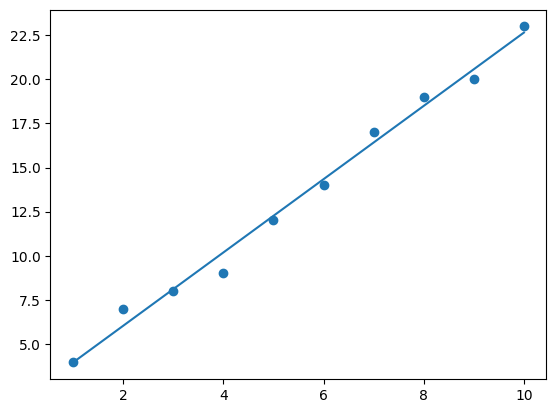

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('st_line_data.csv')

x = df['x'].values
y = df['y'].values

n = 10
m = (n*np.sum(x*y)-np.sum(x)*np.sum(y))/(n*np.sum(x**2)- (np.sum(x))**2)
c = (np.sum(y)- m*np.sum(x))/n 


plt.scatter(x, y)
plt.plot(x, m*x + c)
plt.show()


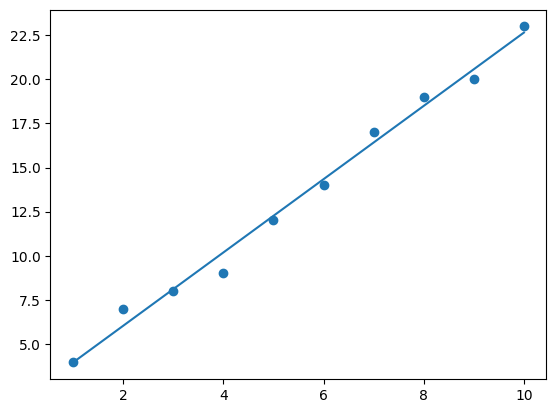

In [35]:
from scipy.optimize import curve_fit 
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('st_line_data.csv')
x = df['x'].values
y = df['y'].values

def f(x,m,c):
    return (m*x + c)
params, covariance = curve_fit(f, x, y)
m, c = params


plt.scatter(x,y)
plt.plot(x, f(x,m,c))
plt.show()


0.9900364376898673
0.05198523728876949
18.168230764826358
good fit


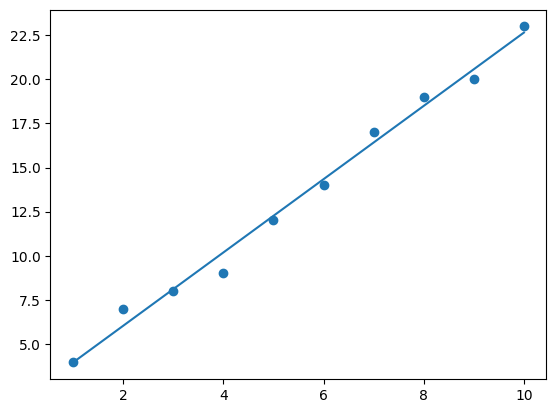

2.078787879281688
1.8666666627218538


In [9]:
from scipy.optimize import curve_fit 
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import chi2

df = pd.read_csv('st_line_data.csv')
x = df['x'].values
y = df['y'].values

def f(x,m,c):
    return (m*x + c)
params, covariance = curve_fit(f, x, y)
m, c = params

y1 = f(x,m,c)
tss = np.sum((y- np.mean(y1))**2)
rss = np.sum((y-y1)**2)

r_squared = 1- (rss/tss)

print(r_squared)

df= len(x)- 2
residuals = y- y1
chi2_stat = np.sum(residuals/(np.sqrt(y1))**2)
critical_value = chi2.ppf(0.98, df)

print(chi2_stat)
print(critical_value)

if chi2_stat< critical_value:
    print("good fit")
else: 
    print("not a good fit")

plt.scatter(x,y)
plt.plot(x, f(x,m,c))
plt.show()
print(m)
print(c)